### Import libraries

In [1]:
import joblib
import matplotlib.pyplot as plt

from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

### Load the TF-IDF Data

In [2]:
X_train = joblib.load("../../data/processed/X_train_tfidf.pkl")
X_val = joblib.load("../../data/processed/X_val_tfidf.pkl")
X_test = joblib.load("../../data/processed/X_test_tfidf.pkl")

y_train = joblib.load("../../data/processed/y_train.pkl")
y_val = joblib.load("../../data/processed/y_val.pkl")
y_test = joblib.load("../../data/processed/y_test.pkl")

### Train the Model

In [3]:
svm_model = LinearSVC(
    class_weight="balanced",
    C=1.0,
    random_state=42,
    max_iter=5000
)

svm_model.fit(X_train, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,verbose,0
,random_state,42


### Training Accuracy

In [4]:
y_train_pred = svm_model.predict(X_train)

train_accuracy = accuracy_score(y_train, y_train_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")

Training Accuracy: 0.9594


### Validation Accuracy

In [5]:
y_val_pred = svm_model.predict(X_val)

val_accuracy = accuracy_score(y_val, y_val_pred)

print(f"Validation Accuracy: {val_accuracy:.4f}")

Validation Accuracy: 0.9134


### Test Accuracy


In [6]:
y_test_pred = svm_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.9142


### Print All Accuracies

In [7]:
print(f"Training Accuracy   : {train_accuracy:.4f}")
print(f"Validation Accuracy : {val_accuracy:.4f}")
print(f"Test Accuracy       : {test_accuracy:.4f}")

Training Accuracy   : 0.9594
Validation Accuracy : 0.9134
Test Accuracy       : 0.9142


### Classification Report

In [8]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

    Negative       0.55      0.63      0.58       347
     Neutral       0.32      0.39      0.35       388
    Positive       0.97      0.95      0.96      8223

    accuracy                           0.91      8958
   macro avg       0.61      0.66      0.63      8958
weighted avg       0.92      0.91      0.92      8958



### Confusion matrix

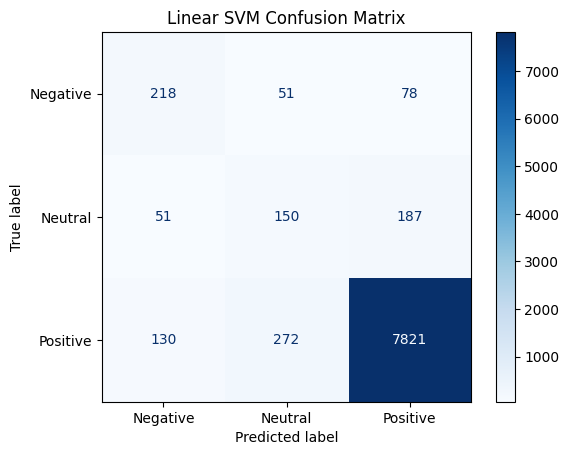

In [9]:
cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=svm_model.classes_
)

disp.plot(cmap="Blues")

plt.title("Linear SVM Confusion Matrix")

plt.show()

### Save the Model

In [10]:
joblib.dump(
    svm_model,
    "../../models/linear_svm.pkl"
)

print("Linear SVM model saved successfully!")

Linear SVM model saved successfully!


### Report conclusion:

Logistic Regression showed consistent performance across the training, validation, and test sets, indicating good generalization. However, its lower overall accuracy suggests that the linear model may not fully capture the complexity of the sentiment classification task.

Random Forest
Training accuracy is almost perfect (99.5%).
Validation and test accuracies are around 94%.
The gap indicates overfitting, although the model still performs very well on unseen data.

Report conclusion:

Random Forest achieved the highest test accuracy (94.17%) among the traditional machine learning models. However, the substantial gap between training and validation/test accuracy indicates overfitting, suggesting the model learned some training-specific patterns.

Linear SVM
Training accuracy (95.94%) is higher than validation/test (~91.4%).
The gap is smaller than Random Forest's.
This indicates mild overfitting while still maintaining good generalization.

Report conclusion:

Linear SVM demonstrated strong performance with a test accuracy of 91.42%. The relatively small difference between training and test accuracy suggests good generalization with only mild overfitting.